# VIP plot

The VIP plot ranks the variables by their Variable Importance in Projection and lays them out as horizontal bars, the largest at the top, with a dashed line at the threshold of one.

    plot_vip(vips; comp = 0, varnames = ..., above = false, ntop = 0, kwargs...)

VIP scores are scaled so their mean square is one, which is what makes the threshold meaningful: a variable above the line contributes more than average, one below it less. Over many variables the sorted bars read as a smooth curve, and the number of important variables is simply where that curve crosses the line.

The VIP is defined for the discriminant models alone and comes from the `vip` function:

| Model | Call |
|---|---|
| `plsda` | `plot_vip(vip(m))` |
| `splsda` | `plot_vip(vip(m))` |

The other models store no VIP. Their variable importance is read from the loadings plot instead.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs


## A simulated example

This notebook uses a wider simulation than the others — two hundred variables rather than twenty — because the sorted bars only read as a curve when there are enough of them to form one. On twenty variables we would see twenty fat bars; on two hundred we see the shape that real data gives.

Three latent signals drive the variables and the class is read off the first, so a handful should stand out well above the threshold while the rest fall below it.

In [2]:
rng = StableRNG(20240801)

n = 120    # observations
p = 200    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

y = [latent[i, 1] > 0.4 ? "a" : latent[i, 1] < -0.4 ? "c" : "b" for i in 1:n]

vnames = ["gene$(i)" for i in 1:p]

m = plsda(X, y, 3)
V = vip(m)

size(V)   # variables by components

(200, 3)

## The default plot

`vip` returns a matrix of variables by components. The scores are cumulative — column `h` is the importance built up through components 1 to `h` — so the **last column is the overall importance**, and that is the one drawn by default.

The variables are always sorted, largest at the top. That is not optional: the layout is a ranked curve, not a plot in variable order, and the ranking is the shape we came to read.

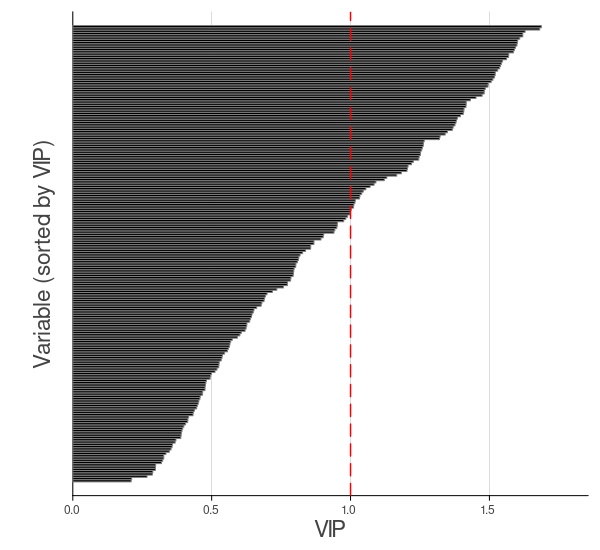

In [3]:
plot_vip(V)

---

# Modifying the plot

Three things are worth separating.

**Which column** — `comp` picks a component, defaulting to `0` for the last. Because the scores are cumulative, `comp = 1` gives the importance from the first component alone, which is a different and usually narrower question.

**How many variables** — `ntop` keeps a fixed count of the highest scorers, while `above` keeps however many clear the threshold, so the count depends on the data. A third knob, `maxnames`, does not filter anything — it only decides whether the variable *names* appear on the axis, since past a few dozen there is no room for a tick each.

**The threshold line** — `threshold` moves it, `thresholdcolor` colors it, `thresholdline = false` removes it.

## Naming and trimming

With two hundred variables the names cannot be shown, so the axis is left bare. Cut the set down with `ntop` and the names appear, provided the count falls under `maxnames` — which defaults to thirty.

Here we take the twenty most important variables and name them. `thresholdline = false` makes the line disappear.

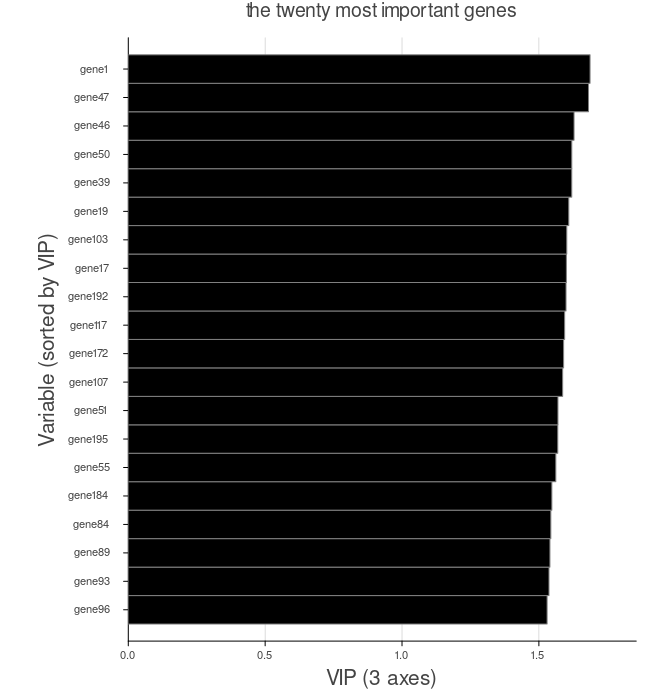

In [9]:
plot_vip(V;
         varnames = vnames,
         ntop     = 20,
         xlabel   = "VIP ($(m.ncomp) axes)",
         title    = "the twenty most important genes",
         thresholdline = false,
         size     = (650, 700))

## Keeping only what clears the line

`above = true` asks a different question: not "the top twenty" but "however many are actually important". The count is whatever the data gives, which is usually what we want when reporting a selection rather than picking a round number.

Raising `maxnames` lets the names show even when more variables survive than the default cutoff allows.

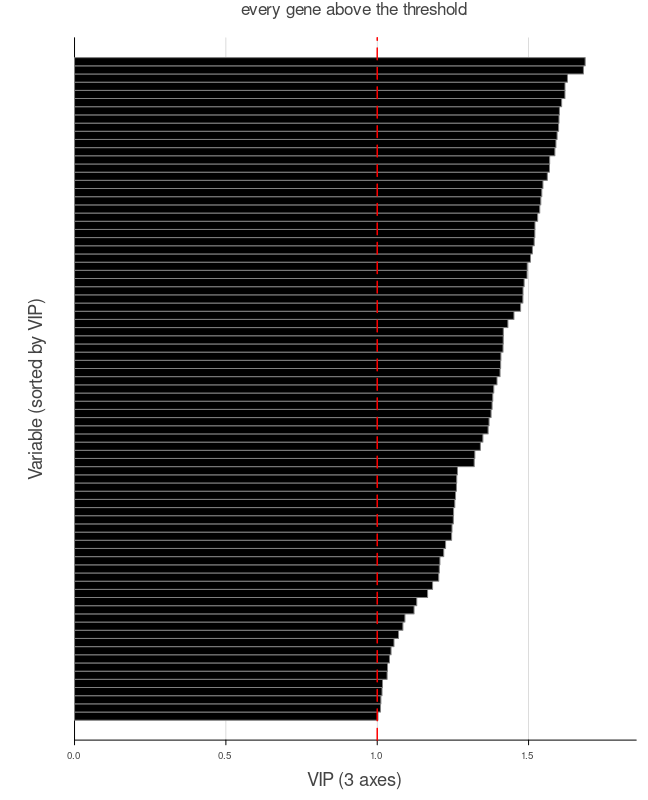

In [10]:
plot_vip(V;
         varnames = vnames,
         above    = true,
         maxnames = 60,
         xlabel   = "VIP ($(m.ncomp) axes)",
         title    = "every gene above the threshold",
         size     = (650, 800))

## The line, the bars, and the rest

The threshold sits at one by default, which is the convention. Moving it to a stricter value is a way of tightening the selection, and since `above` filters against whatever `threshold` is set to, the two work together — `threshold = 1.2, above = true` keeps only the variables clearing the stricter bar.

`vipcolor` fills the bars and `vipedgecolor` outlines them. Everything else is a standard attribute and yields to what we pass.

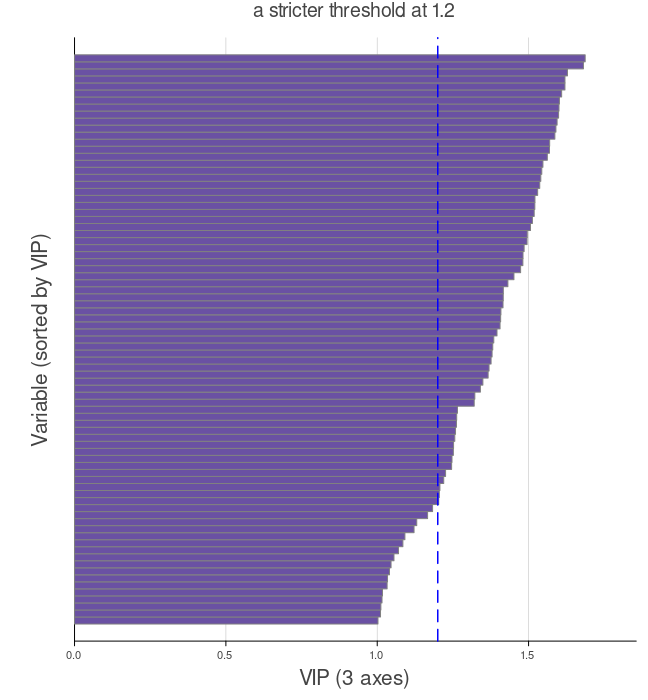

In [11]:
plot_vip(V;
         varnames       = vnames,
         threshold      = 1.2,
         above          = true,
         thresholdcolor = :blue,
         vipcolor       = "#6a51a3",
         vipedgecolor   = :grey,
         maxnames       = 40,
         xlabel         = "VIP ($(m.ncomp) axes)",
         title          = "a stricter threshold at 1.2",
         size           = (650, 700))